In [17]:
%pip install -q langchain langchain-google-genai google-generativeai

Note: you may need to restart the kernel to use updated packages.


In [18]:
%pip install python-dotenv

Note: you may need to restart the kernel to use updated packages.


In [19]:
import os
from dotenv import load_dotenv

load_dotenv()

GEMINI_API_KEY = os.getenv('GEMINI_API_KEY')

In [20]:
from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI(
    model="gemini-3.1-flash-lite",
    temperature=0,
    google_api_key=GEMINI_API_KEY
)

In [21]:
respuesta = llm.invoke("¿Qué es el RAG en Inteligencia Artificial?")

In [22]:
respuesta.content

[{'type': 'text',
  'text': '**RAG** son las siglas en inglés de **Retrieval-Augmented Generation** (Generación Aumentada por Recuperación).\n\nEn términos sencillos, es una técnica que permite a los modelos de lenguaje (como ChatGPT) **consultar información externa y actualizada** antes de generar una respuesta, en lugar de depender únicamente de los datos con los que fueron entrenados originalmente.\n\nAquí te explico cómo funciona y por qué es tan importante:\n\n---\n\n### 1. El problema: ¿Por qué necesitamos RAG?\nLos modelos de lenguaje (LLMs) tienen dos limitaciones principales:\n*   **Conocimiento estático:** Su entrenamiento termina en una fecha específica. No saben qué pasó hoy o ayer.\n*   **Alucinaciones:** Si les preguntas algo que no saben, a menudo inventan una respuesta que suena convincente pero es falsa.\n*   **Datos privados:** No conocen tus documentos personales, correos o archivos internos de una empresa.\n\n### 2. ¿Cómo funciona el RAG? (El proceso)\nImagina que e

In [23]:
PROMPT_TRIAJE = """
Eres un especialista en triaje del Service Desk para politicas internas.
Dado el mensaje del usuario, devuelve SÓLO un JSON con:\n
{\n
    "decision": "AUTO_RESOLVER" | "PEDIR_INFO" | "ABRIR_TICKET",\n
    "urgency": "BAJA" | "MEDIANA" | "ALTA",\n
    "missing_fields": ["..."]\n
}\n
Reglas:\n
- **AUTO_RESOLVER**: Preguntas claras sobre las reglas o procedimientos descritos en las politicas (Ej.: "¿Puedo reembolsar el internet para mi oficina en casa?").\n
- **PEDIR_INFO**: Mensajes imprecisos o sin información para identificar el tema o el contexto (Ej.: "Necesito ayuda con una politica").\n
- **ABRIR_TICKET**: Solicitudes de excepciones, autorización, aprobación o acceso especial, o cuando el usuario solicita explicitamente abrir un ticket (Ej.: "Quiero una excepción para trabajar remotamente durante 5 dias").\n
Analiza el mensaje y decide la acción más adecuada.
"""

In [24]:
from typing import Literal, List, Dict
from pydantic import BaseModel, Field

class TriajeOut(BaseModel):
    decision: Literal["AUTO_RESOLVER", "PEDIR_INFO", "ABRIR_TICKET"]
    urgencia: Literal["BAJA", "MEDIANA", "ALTA"]
    campos_faltantes: List[str] = Field(default_factory=list)

In [25]:
from langchain_core.messages import SystemMessage, HumanMessage

chain_de_triaje = llm.with_structured_output(TriajeOut)

def triaje(mensaje: str) -> Dict:
    salida: TriajeOut = chain_de_triaje.invoke(
        [
            SystemMessage(content=PROMPT_TRIAJE),
            HumanMessage(content=mensaje)
        ]
    )
    return salida.model_dump()


In [26]:
mensajes_de_prueba = [
    "¿Puedo obtener un reembolso por el internet de mi home office?",
    "Quiero una excepción para teletrabajar durante 5 días.",
    "¿Cómo funciona la política de comidas para viajes?",
    "¿Existe una política para anticipos de vacaciones?",
    "¿Quién fue Napoleón Bonaparte?"
]

In [27]:
for pregunta in mensajes_de_prueba:
    r = triaje(pregunta)
    print(f"{pregunta} -> {r}")

¿Puedo obtener un reembolso por el internet de mi home office? -> {'decision': 'AUTO_RESOLVER', 'urgencia': 'BAJA', 'campos_faltantes': []}
Quiero una excepción para teletrabajar durante 5 días. -> {'decision': 'ABRIR_TICKET', 'urgencia': 'MEDIANA', 'campos_faltantes': ['fecha_inicio', 'motivo_de_la_excepcion', 'nombre_del_empleado']}
¿Cómo funciona la política de comidas para viajes? -> {'decision': 'AUTO_RESOLVER', 'urgencia': 'BAJA', 'campos_faltantes': []}
¿Existe una política para anticipos de vacaciones? -> {'decision': 'AUTO_RESOLVER', 'urgencia': 'BAJA', 'campos_faltantes': []}
¿Quién fue Napoleón Bonaparte? -> {'decision': 'AUTO_RESOLVER', 'urgencia': 'BAJA', 'campos_faltantes': []}


##### Aula 2

In [28]:
%pip install -q langchain_community faiss-cpu langchain-text-splitters pymupdf

Note: you may need to restart the kernel to use updated packages.


In [29]:
from pathlib import Path
from langchain_community.document_loaders import PyMuPDFLoader

docs = []

for n in Path("C:\\Users\\machi\\Desktop\\tech_ai_builder\\temp\\RAG-Y-AGENTES-IA").glob("*.pdf"):
    try:
        loader = PyMuPDFLoader(str(n))
        docs.extend(loader.load())
        print(f"Archivo cargado: {n.name}")
    except Exception as e:
        print(f"Error cargando archivo: {n.name}: {e}")

print(f"Total de documentos cargados: {len(docs)}")

C:\Users\machi\AppData\Local\Temp\ipykernel_23052\2969742635.py:2: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyMuPDFLoader


Archivo cargado: Política de Reembolsos (Viajes y Gastos).pdf
Archivo cargado: Política de Teletrabajo (Home Office).pdf
Archivo cargado: Política de Uso de Correo Electrónico y Seguridad de la Información.pdf
Total de documentos cargados: 3


In [30]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

splitter = RecursiveCharacterTextSplitter(chunk_size=300, chunk_overlap=30)
chunks = splitter.split_documents(docs)

for chunk in chunks:
    print(chunk)
    print("-----------------")

page_content='Política de Reembolsos (Viajes y 
Gastos) 
1. Objetivo Establecer las directrices y procedimientos para el reembolso de gastos 
incurridos por los empleados en el ejercicio de sus funciones oficiales, asegurando la 
transparencia, equidad y cumplimiento fiscal.' metadata={'producer': 'Skia/PDF m143 Google Docs Renderer', 'creator': '', 'creationdate': '', 'source': 'C:\\Users\\machi\\Desktop\\tech_ai_builder\\temp\\RAG-Y-AGENTES-IA\\Política de Reembolsos (Viajes y Gastos).pdf', 'file_path': 'C:\\Users\\machi\\Desktop\\tech_ai_builder\\temp\\RAG-Y-AGENTES-IA\\Política de Reembolsos (Viajes y Gastos).pdf', 'total_pages': 1, 'format': 'PDF 1.4', 'title': 'Política de Reembolsos (Viajes y Gastos)', 'author': '', 'subject': '', 'keywords': '', 'moddate': '', 'trapped': '', 'modDate': '', 'creationDate': '', 'page': 0}
-----------------
page_content='2. Ámbito de Aplicación Esta política se aplica a todos los empleados fijos y temporales 
que incurran en gastos en nombre de la

In [31]:
from langchain_google_genai import GoogleGenerativeAIEmbeddings

modelo_embeddings = GoogleGenerativeAIEmbeddings(
    model="models/gemini-embedding-001",
    google_api_key=GEMINI_API_KEY
)

In [32]:
from langchain_community.vectorstores import FAISS

vectorstore = FAISS.from_documents(chunks, modelo_embeddings)
retriever = vectorstore.as_retriever(
    search_type="similarity_score_threshold",
    search_kwargs={"score_threshold": 0.3, "k": 4}
)

In [33]:
%pip install -q -U langchain-classic

Note: you may need to restart the kernel to use updated packages.


In [34]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_classic.chains.combine_documents import create_stuff_documents_chain

prompt_rag = ChatPromptTemplate(
    [
        ("system",
            """Eres el especialista en RR.HH. de la empresa Carraro Desarrollo de Software.
            Responde siempre utilizando los conocimientos de las bases de datos pasadas a ti.
            Si no hay informacion sobre la pregunta en los datos, responde solo 'No lo se'.
            """
        ),
        ("human", "Contexto: {context}\nPregunta del empleado: {input}")
    ]
)

document_chain = create_stuff_documents_chain(llm, prompt_rag)

In [35]:
def busqueda_de_respuestas_RAG(pregunta) -> Dict:
    documentos_relacionados = retriever.invoke(pregunta)
    
    if not documentos_relacionados:
        return {
            "respuesta": "No lo sé",
            "citaciones": [],
            "documentos_encontrados": False
        }

    answer = document_chain.invoke({
        "input": pregunta,
        "context": documentos_relacionados
    })

    if answer.rstrip(".!?") == "No lo sé":
        return {
            "respuesta": "No lo sé",
            "citaciones": [],
            "documentos_encontrados": False
        }
    
    return {
        "respuesta": answer,
        "citaciones": documentos_relacionados,
        "documentos_encontrados": True
    }

In [36]:
r = busqueda_de_respuestas_RAG("¿Puedo obtener un reembolso por el internet de mi home office?")
print(r)

{'respuesta': 'Sí, los empleados bajo el modelo de trabajo remoto (Home Office) aprobado pueden solicitar un reembolso mensual de hasta 35 EUR para gastos de conexión a internet, presentando la factura correspondiente.', 'citaciones': [Document(id='8347eb5c-8e4a-42dd-9a34-7f3dd601b1f9', metadata={'producer': 'Skia/PDF m143 Google Docs Renderer', 'creator': '', 'creationdate': '', 'source': 'C:\\Users\\machi\\Desktop\\tech_ai_builder\\temp\\RAG-Y-AGENTES-IA\\Política de Reembolsos (Viajes y Gastos).pdf', 'file_path': 'C:\\Users\\machi\\Desktop\\tech_ai_builder\\temp\\RAG-Y-AGENTES-IA\\Política de Reembolsos (Viajes y Gastos).pdf', 'total_pages': 1, 'format': 'PDF 1.4', 'title': 'Política de Reembolsos (Viajes y Gastos)', 'author': '', 'subject': '', 'keywords': '', 'moddate': '', 'trapped': '', 'modDate': '', 'creationDate': '', 'page': 0}, page_content='con recibo. \n●\u200b Internet (Home Office): Los empleados bajo el modelo de trabajo remoto (Home \nOffice) aprobado (ver Política de

In [37]:
len(r["citaciones"])

4

In [38]:
for pregunta in mensajes_de_prueba:
    respuesta_RAG = busqueda_de_respuestas_RAG(pregunta)
    print(f"PREGUNTA: {pregunta}")
    print(f"RESPUESTA: {respuesta_RAG['respuesta']}")
    if respuesta_RAG["documentos_encontrados"]:
        for i, citacion in enumerate(respuesta_RAG['citaciones']):
            print(f"     - CITACION {i + 1}:")
            print(f"      Camino del documento: {citacion.metadata['file_path']}")
            print(f"      Contenido: {citacion.page_content.replace('\n', '')}")
print("--------------------------------------------------------")

PREGUNTA: ¿Puedo obtener un reembolso por el internet de mi home office?
RESPUESTA: Sí, los empleados bajo el modelo de trabajo remoto (Home Office) aprobado pueden solicitar un reembolso mensual de hasta 35 EUR para gastos de conexión a internet, presentando la factura correspondiente.
     - CITACION 1:
      Camino del documento: C:\Users\machi\Desktop\tech_ai_builder\temp\RAG-Y-AGENTES-IA\Política de Reembolsos (Viajes y Gastos).pdf
      Contenido: con recibo. ●​ Internet (Home Office): Los empleados bajo el modelo de trabajo remoto (Home Office) aprobado (ver Política de Home Office) pueden solicitar un reembolso mensual de hasta 35 EUR para gastos de conexión a internet, presentando la factura correspondiente.
     - CITACION 2:
      Camino del documento: C:\Users\machi\Desktop\tech_ai_builder\temp\RAG-Y-AGENTES-IA\Política de Teletrabajo (Home Office).pdf
      Contenido: en esta modalidad pueden solicitar el reembolso de gastos de internet hasta el límite establecido (35 EUR/

##### Aula 3

In [39]:
%pip install -q langgraph

Note: you may need to restart the kernel to use updated packages.


In [40]:
from typing import TypedDict, Optional

class AgentState(TypedDict, total=False):
    pregunta: str
    triaje: dict
    respuesta: Optional[str]
    citaciones: Optional[list]
    documentos_encontrados: Optional[bool]
    rag_exito: bool
    accion_final: str

In [41]:
def nodo_triaje(state: AgentState) -> AgentState:
    print("ejecutando nodo triaje...")
    return {"triaje": triaje(state["pregunta"])}

In [42]:
def nodo_auto_resolver(state: AgentState) -> AgentState:
    print("Ejecutando nodo 'auto_resolver'...")
    respuesta_RAG = busqueda_de_respuestas_RAG(state["pregunta"])

    update: AgentState = {
        "respuesta": respuesta_RAG["respuesta"],
        "citaciones": respuesta_RAG["citaciones"],
        "rag_exito": respuesta_RAG["documentos_encontrados"]
    }

    if respuesta_RAG["documentos_encontrados"]:
        update["accion_final"] = "AUTO_RESOLVER"
    else:
        update["accion_final"] = "pedir_info"

    return update

In [43]:
def nodo_pedir_info(state: AgentState) -> AgentState:
    print("Ejecutando nodo 'pedir_info'...")
    return {
        "respuesta": "Necesito más informaciones sobre tu pedido.",
        "citaciones": [],
        "accion_final": "PEDIR_INFO"
    }

In [44]:
def nodo_abrir_ticket(state: AgentState) -> AgentState:
    print("Ejecutando nodo 'abrir_ticket'...")
    tri = state["triaje"]
    return {
        "respuesta": f"Abrir ticket con urgencia {tri['urgencia']}. Pedido: {state['pregunta']}.",
        "citaciones": [],
        "accion_final": "ABRIR_TICKET"
    }

In [45]:
def arista_decision_triaje(state: AgentState) -> str:
    print("Decidiendo el flujo después del nodo 'triaje'...")
    tri = state["triaje"]
    
    if tri["decision"] == "AUTO_RESOLVER":
        return "rag"
    elif tri["decision"] == "PEDIR_INFO":
        return "info"
    else:
        return "ticket"

In [46]:
def arista_decision_rag(state: AgentState) -> str:
    print("Decidiendo el flujo después del nodo 'auto_resolver'...")
    if state["rag_exito"]:
        print("RAG con exito, finalizando el flujo.")
        return "ok"
    
    KEYWORDS_ABRIR_TICKET = ["aprobación", "aprobar", "excepción", "liberación", "autorización",
                           "autorizar", "abrir ticket", "acceso especial"]

    if any(keyword in state["pregunta"].lower() for keyword in KEYWORDS_ABRIR_TICKET):
        print("RAG ha fallado, pero hay palabras relacionadas con abrir ticket.")
        return "ticket"
    
    print("RAG ha fallado, pediré más informaciones al usuario.")
    return "info"

In [47]:
from langgraph.graph import START, END, StateGraph

workflow = StateGraph(AgentState)

workflow.add_node("triaje", nodo_triaje)
workflow.add_node("auto_resolver", nodo_auto_resolver)
workflow.add_node("pedir_info", nodo_pedir_info)
workflow.add_node("abrir_ticket", nodo_abrir_ticket)

workflow.add_edge(START, "triaje")

workflow.add_conditional_edges("triaje", arista_decision_triaje, {
    "rag": "auto_resolver",
    "info": "pedir_info",
    "ticket": "abrir_ticket"
})

workflow.add_conditional_edges("auto_resolver", arista_decision_rag, {
    "info": "pedir_info",
    "ticket": "abrir_ticket",
    "ok": END
});

workflow.add_edge("pedir_info", END)
workflow.add_edge("abrir_ticket", END)

grafo = workflow.compile()

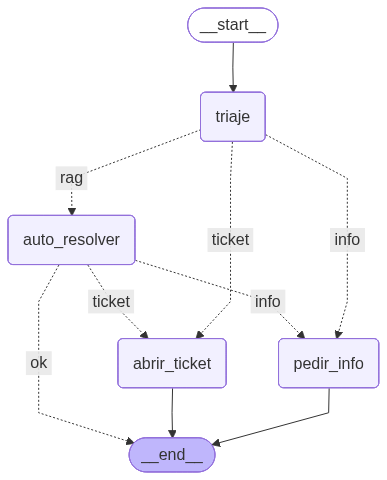

In [48]:
from IPython.display import display, Image

graph_bytes = grafo.get_graph().draw_mermaid_png()
display(Image(graph_bytes))

##### Aula 4

In [51]:
PREGUNTA = "Puedo reembolsar mi internet?"
temp = grafo.invoke({"pregunta": PREGUNTA})
print(f"PREGUNTA: {PREGUNTA}")
print(f"DECISION: {temp['triaje']['decision']} | URGENCIA: {temp['triaje']['urgencia']} | ACCCION FINAL: {temp['accion_final']}")
print(f"RESPUESTA: {temp['respuesta']}")
if temp['citaciones']:
    for i, citacion in enumerate(temp['citaciones']):
        print(f"  - CITACION {i + 1}:")
        print(f"    Camino del documento: {citacion.metadata['file_path']}")
        print(f"    Contenido: {citacion.page_content.replace('\n', ' ')}")

ejecutando nodo triaje...
Decidiendo el flujo después del nodo 'triaje'...
Ejecutando nodo 'auto_resolver'...
Decidiendo el flujo después del nodo 'auto_resolver'...
RAG con exito, finalizando el flujo.
PREGUNTA: Puedo reembolsar mi internet?
DECISION: AUTO_RESOLVER | URGENCIA: BAJA | ACCCION FINAL: AUTO_RESOLVER
RESPUESTA: Sí, los empleados bajo el modelo de trabajo remoto (Home Office) aprobado pueden solicitar un reembolso mensual de hasta 35 EUR para gastos de conexión a internet, presentando la factura correspondiente.
  - CITACION 1:
    Camino del documento: C:\Users\machi\Desktop\tech_ai_builder\temp\RAG-Y-AGENTES-IA\Política de Reembolsos (Viajes y Gastos).pdf
    Contenido: con recibo.  ●​ Internet (Home Office): Los empleados bajo el modelo de trabajo remoto (Home  Office) aprobado (ver Política de Home Office) pueden solicitar un reembolso  mensual de hasta 35 EUR para gastos de conexión a internet, presentando la  factura correspondiente.
  - CITACION 2:
    Camino del doc

In [52]:
mensajes_de_prueba = [
    "¿Puedo obtener un reembolso por el internet de mi home office?",
    "Quiero una excepción para teletrabajar durante 5 días.",
    "¿Cómo funciona la política de comidas para viajes?",
    "¿Existe una política para anticipos de vacaciones?",
    "¿Quién fue Napoleón Bonaparte?"
]

In [54]:
for prueba in mensajes_de_prueba:
    temp = grafo.invoke({"pregunta": prueba})
    print("")
    print(f"PREGUNTA: {prueba}")
    print(f"DECISION: {temp['triaje']['decision']} | URGENCIA: {temp['triaje']['urgencia']} | ACCCION FINAL: {temp['accion_final']}")
    print(f"RESPUESTA: {temp['respuesta']}")
    if temp['citaciones']:
        for i, citacion in enumerate(temp['citaciones']):
            print(f"  - CITACION {i + 1}:")
            print(f"    Camino del documento: {citacion.metadata['file_path']}")
            print(f"    Contenido: {citacion.page_content.replace('\n', ' ')}")
print("--------------------------------------------------------")

ejecutando nodo triaje...
Decidiendo el flujo después del nodo 'triaje'...
Ejecutando nodo 'auto_resolver'...
Decidiendo el flujo después del nodo 'auto_resolver'...
RAG con exito, finalizando el flujo.

PREGUNTA: ¿Puedo obtener un reembolso por el internet de mi home office?
DECISION: AUTO_RESOLVER | URGENCIA: BAJA | ACCCION FINAL: AUTO_RESOLVER
RESPUESTA: Sí, los empleados bajo el modelo de trabajo remoto (Home Office) aprobado pueden solicitar un reembolso mensual de hasta 35 EUR para gastos de conexión a internet, presentando la factura correspondiente.
  - CITACION 1:
    Camino del documento: C:\Users\machi\Desktop\tech_ai_builder\temp\RAG-Y-AGENTES-IA\Política de Reembolsos (Viajes y Gastos).pdf
    Contenido: con recibo.  ●​ Internet (Home Office): Los empleados bajo el modelo de trabajo remoto (Home  Office) aprobado (ver Política de Home Office) pueden solicitar un reembolso  mensual de hasta 35 EUR para gastos de conexión a internet, presentando la  factura correspondiente.
